In [2]:
import os
import sys
import django
from dotenv import load_dotenv
import pandas as pd
from sentence_transformers import SentenceTransformer
from umap import UMAP
import hdbscan
from sklearn.neighbors import NearestNeighbors
from statistics import mode
from tqdm import tqdm



In [3]:
# --- 1. Setup Paths ---
# Point to the 'src' folder inside jao-backend
current_dir = os.path.abspath('.')
sys.path.append(os.path.join(current_dir, 'jao-backend', 'src'))

# --- 2. Load Environment Variables ---
load_dotenv('.env')

# --- 3. FIX THE DATABASE URL ---
# Your .env likely uses 'host.docker.internal' or 'db' for Docker.
# Since we are running on your Mac, we must force this to 'localhost'.
current_db_url = os.environ.get("JAO_BACKEND_DATABASE_URL", "")

if "host.docker.internal" in current_db_url:
    # Fix: Replace host.docker.internal with localhost
    new_url = current_db_url.replace("host.docker.internal", "localhost")
    os.environ["JAO_BACKEND_DATABASE_URL"] = new_url
    print(f"🔌 Patched DB URL for local access: ...@{new_url.split('@')[1]}")

elif "@db" in current_db_url:
    # Fix: Replace docker service name 'db' with localhost
    new_url = current_db_url.replace("@db", "@localhost")
    os.environ["JAO_BACKEND_DATABASE_URL"] = new_url
    print(f"🔌 Patched DB URL for local access: ...@{new_url.split('@')[1]}")

# --- 4. Initialize Django ---
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'jao_backend.settings.dev')
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true" # Required for notebooks
django.setup()

print("✅ Django loaded successfully.")

🔌 Patched DB URL for local access: ...@localhost:5432/jao-backend?gssencmode=disable


/Users/colm.reid/.pyenv/versions/myenv312/lib/python3.12/site-packages/polymorphic/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


✅ Django loaded successfully.


/Users/colm.reid/.pyenv/versions/myenv312/lib/python3.12/site-packages/pydantic/_internal/_model_construction.py:63: UserWarning: `validate_last_updated` overrides an existing Pydantic `@field_validator` decorator
  warnings.warn(f'`{k}` overrides an existing Pydantic `{existing.decorator_info.decorator_repr}` decorator')


In [4]:
from jao_backend.skills.models import Skill


In [5]:
all_skill_objects = list(Skill.objects.all())

In [6]:
all_skill_names = [s.name for s in all_skill_objects]

print(f"Loaded {len(all_skill_names)} unique skills from the database.")
print(f"Examples: {all_skill_names[:10]}")

Loaded 41300 unique skills from the database.
Examples: ['answering the telephone.', 'budget forecast returns', 'working effectively in accounting  2011 october', 'arranging meetings with stakeholders', 'give regular updates', 'dealing with returns and queries', 'video conferencing', 'deliver on the whole of government accounts', 'work alone and as part of the team', 'developing the process and used my skills with academies']


In [7]:
from sentence_transformers import SentenceTransformer
import pandas as pd
from umap import UMAP
import hdbscan

In [8]:
sentence_model = SentenceTransformer("all-MiniLM-L6-v2")
unique_skills_embeddings = sentence_model.encode(all_skill_names, show_progress_bar=True)

INFO Use pytorch device_name: mps
INFO Load pretrained SentenceTransformer: all-MiniLM-L6-v2
/Users/colm.reid/.pyenv/versions/myenv312/lib/python3.12/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/1291 [00:00<?, ?it/s]

In [9]:
umap_reducer = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, random_state=42)
umap_embedding = umap_reducer.fit_transform(unique_skills_embeddings)

/Users/colm.reid/.pyenv/versions/myenv312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


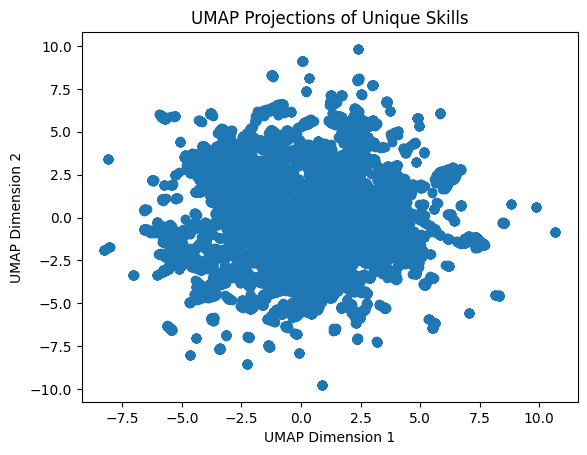

In [10]:
import matplotlib.pyplot as plt

plt.scatter(umap_embedding[:,0],umap_embedding[:, 1])
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('UMAP Projections of Unique Skills')

plt.show()

In [11]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=10, metric='euclidean', cluster_selection_method='eom')
cluster_labels = clusterer.fit_predict(umap_embedding)

/Users/colm.reid/.pyenv/versions/myenv312/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/colm.reid/.pyenv/versions/myenv312/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before th

In [12]:
unique_skills_df = pd.DataFrame({'Skills': all_skill_names, 'Cluster': cluster_labels})

In [13]:
unique_skills_df.head(20)

,Skills,Cluster
0,answering the telephone.,140
1,budget forecast returns,360
2,working effectively in accounting 2011 october,362
3,arranging meetings with stakeholders,106
4,give regular updates,569
5,dealing with returns and queries,33
6,video conferencing,-1
7,deliver on the whole of government accounts,363
8,work alone and as part of the team,-1
9,developing the process and used my skills with...,603


In [14]:
unique_skills_df[unique_skills_df['Cluster'] == 583].head(20)

,Skills,Cluster
12,using specific software,583
1135,use specific software,583
4008,using various computer systems,583
6315,use in-­-house computer software systems,583
9019,install software,583
9398,build adaptable software,583
10144,trouble-shooting both on software,583
11626,uses different software called selestia,583
11782,run many software,583
14598,specialised software,583


In [15]:
unique_skills_df.shape

(41300, 2)

In [16]:
import numpy as np
print(np.unique(cluster_labels).size)

680


In [17]:
# Identify noise points in the original DataFrame
noise_points = unique_skills_df[unique_skills_df['Cluster'] == -1]

In [18]:
# Compute centroids of each cluster using UMAP embeddings
cluster_centroids = umap_embedding[unique_skills_df['Cluster'] != -1]
cluster_centroids_labels = unique_skills_df['Cluster'][unique_skills_df['Cluster'] != -1]

In [19]:
# Use KNN to assign each noise point to the nearest cluster based on centroids
knn = NearestNeighbors(n_neighbors=1)
knn.fit(cluster_centroids)

,n_neighbors,1
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,None


In [20]:
# Find the nearest cluster for each unique noise skill
unique_noise_skills = noise_points['Skills'].unique()
unique_noise_embeddings = sentence_model.encode(unique_noise_skills, show_progress_bar=True)

Batches:   0%|          | 0/286 [00:00<?, ?it/s]

In [21]:
# Ensure the embeddings are reshaped if necessary
if len(unique_noise_embeddings.shape) > 1:
    unique_noise_embeddings = unique_noise_embeddings[:, :2]  # Assuming you only need the first two dimensions

nearest_clusters = []

with tqdm(total=len(unique_noise_embeddings), desc="Assigning noise points") as pbar:
    for emb in unique_noise_embeddings:
        _, nearest_cluster = knn.kneighbors([emb])
        nearest_clusters.append(nearest_cluster[0][0])
        pbar.update(1)

Assigning noise points: 100%|██████████| 9150/9150 [00:01<00:00, 7015.38it/s]


In [22]:
# Create a mapping of noise skills to their nearest cluster
noise_skill_to_cluster = dict(zip(unique_noise_skills, cluster_centroids_labels.iloc[nearest_clusters].values))

In [23]:
# Assign each noise point to the nearest cluster using the mapping
noise_points['Cluster'] = noise_points['Skills'].map(noise_skill_to_cluster)

/var/folders/x8/wq9wld7n7bxfpfpwr3p0ms6c0000gp/T/ipykernel_39625/1596379153.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  noise_points['Cluster'] = noise_points['Skills'].map(noise_skill_to_cluster)


In [24]:
# Check if 'Cluster' column is created correctly
print("Columns in noise_points after mapping:", noise_points.columns)

Columns in noise_points after mapping: Index(['Skills', 'Cluster'], dtype='object')


In [25]:
# Update the cluster labels in the original DataFrame
unique_skills_df.loc[unique_skills_df['Cluster'] == -1, 'Cluster'] = noise_points['Cluster'].values

In [26]:
# Check the updated DataFrame structure
print("Columns in stacked_df_with_clusters after updating:", unique_skills_df.columns)

Columns in stacked_df_with_clusters after updating: Index(['Skills', 'Cluster'], dtype='object')


In [27]:
# Group by 'Cluster' and aggregate remaining columns into lists again
grouped_df = unique_skills_df.groupby('Cluster').agg(lambda x: list(x))

In [30]:
grouped_df.head()

,Skills
Cluster,
0,"[managing workflow, managing workflows, workfl..."
1,"[sprint planning and sprint reviews and tools,..."
2,[identifying appropriate companies for a merge...
3,"[distributing and analysing questionnaires, de..."
4,"[copying survey data, surveys, surveying pract..."


In [32]:
import litellm
import pandas as pd
from tqdm.auto import tqdm
from jao_backend.common.litellm.model_list import OllamaModelList

In [33]:
# --- 1. Check if Ollama is running ---
if not OllamaModelList.is_available():
    print("❌ ERROR: Ollama server is not running.")
    print("Please start your local Ollama server to continue.")
else:
    print(f"✅ Ollama server is running. Models: {OllamaModelList.get_model_list()}")
    
# Register tqdm for use with pandas .apply()
tqdm.pandas(desc="Naming Clusters")

✅ Ollama server is running. Models: ['mistral:7b', 'nomic-embed-text:latest']


In [34]:
# --- 2. Define the Naming Function ---
def name_cluster(skill_list):
    """
    Takes a list of skill strings and returns a 2-3 word
    category name for the cluster using an LLM.
    """
    # Create a clean, comma-separated string for the prompt
    # We sample the first 30 skills so the prompt isn't too long
    if len(skill_list) > 30:
        skill_sample = ", ".join(skill_list[:30]) + ", etc."
    else:
        skill_sample = ", ".join(skill_list)

    # Define the prompts
    system_prompt = (
        "You are an expert in HR and data analysis. Your job is to look at a list "
        "of skills from a job and find a single, concise, 2-3 word category name "
        "for that group. Respond with *only* the category name and nothing else."
    )
    
    user_prompt = (
        f"Here is a list of skills: [{skill_sample}]. "
        "What is the best 2-3 word category name for this group? "
        "(e.g., 'Data Analysis', 'Web Development', 'Project Management')"
    )

    try:
        # --- 3. Call the LLM (Ollama) ---
        response = litellm.completion(
            # 'ollama/mistral:7b' (or 'ollama/llama3') is a common model
            # This 'model' name comes from your settings/model_list.py
            model=f"{OllamaModelList.LITELLM_MODEL_PREFIX}/mistral:7b", 
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            max_tokens=20,     # We just need a short name
            temperature=0.1  # We want consistent, non-creative names
        )
        
        # --- 4. Clean the Response ---
        name = response.choices[0].message.content.strip().replace('"', '')
        return name

    except Exception as e:
        print(f"Error calling LLM: {e}")
        return "[Error]"

In [37]:
print("--- Testing on the first 5 clusters ---")
test_df = grouped_df.head(5).copy()

# Use .progress_apply() to see a progress bar
test_df['Cluster_Name'] = test_df['Skills'].progress_apply(name_cluster)

print("\n--- Test Results ---")
# Display the full list of skills for context
pd.set_option('display.max_colwidth', None)
test_df_to_print = test_df.reset_index()
print(test_df_to_print[['Cluster', 'Cluster_Name', 'Skills']])

--- Testing on the first 5 clusters ---


Naming Clusters:   0%|          | 0/5 [00:00<?, ?it/s]

14:49:17 - LiteLLM:INFO: utils.py:3347 - 
LiteLLM completion() model= mistral:7b; provider = ollama
INFO 
LiteLLM completion() model= mistral:7b; provider = ollama
14:49:18 - LiteLLM:INFO: utils.py:1273 - Wrapper: Completed Call, calling success_handler
INFO Wrapper: Completed Call, calling success_handler
14:49:18 - LiteLLM:INFO: utils.py:3347 - 
LiteLLM completion() model= mistral:7b; provider = ollama
INFO 
LiteLLM completion() model= mistral:7b; provider = ollama
14:49:19 - LiteLLM:INFO: utils.py:1273 - Wrapper: Completed Call, calling success_handler
INFO Wrapper: Completed Call, calling success_handler
14:49:19 - LiteLLM:INFO: utils.py:3347 - 
LiteLLM completion() model= mistral:7b; provider = ollama
INFO 
LiteLLM completion() model= mistral:7b; provider = ollama
14:49:20 - LiteLLM:INFO: utils.py:1273 - Wrapper: Completed Call, calling success_handler
INFO Wrapper: Completed Call, calling success_handler
14:49:20 - LiteLLM:INFO: utils.py:3347 - 
LiteLLM completion() model= mistra


--- Test Results ---
   Cluster                     Cluster_Name  \
0        0              Workflow Management   
1        1              Agile Methodologies   
2        2          Merger Control & Policy   
3        3  Questionnaire Design & Analysis   
4        4           Survey & Data Analysis   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       